In [1]:
import imageio

import numpy as np

import matplotlib.pyplot as plt

from tqdm import tqdm
from pathlib import Path

from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Helper function

In [2]:
def save_gif(
    images, 
    save_dir,
    file_name = 'GIF.gif',
    loop = 0,
    duration = 500
):
    
    '''
    Save a stack of image in as a GIF
    
    image: list(ndimage)          Stack of images to loop
    save_dir: pathlib.Path        Path to the directory where to save the GIF
    tag: str                      Default ('GIF') entities for unique saving name
    loop: int                     Default (0 for infinity loop) Number of loop                        
    duration: int                 Default (500ms) Duration of each fram in ms
    '''
    
    save_name = save_dir / file_name
    imageio.mimsave(save_name, images, loop = loop, duration = duration)
    
    return save_name

# General Parameters

In [3]:
# General parameters

dr = 1
dTheta = 2*np.pi/10

nb_theta_mesh = 100

# sequence

################################## Smoothest curve

# sequence = np.array([10,20,30,40,50,60,70,80,90])
# sequence = sequence - np.array([0,1,3,7,12,18,25,33,42])

################################## extended smooth

# sequence = [10]
# increments = [0,0,0,1,1,2,3,4,5,6,7,7,8,8,8]
# for inc in increments:
#     sequence.append(sequence[-1]+10-inc)

################################## arbitrary test

############## Fully manual

# sequence = np.array([10,20,30,40,50,60,70,80,90,100])

############## decrement encoding

sequence = [10]
d_increment = [10, 9, 9, 8, 8 ,7, 7, 6, 6, 5, 5, 4 ,3 ,2 ,1]
for dinc in d_increment:
    sequence.append(sequence[-1]+dinc)

print(sequence)
print(np.diff(sequence))
print(np.diff(sequence)-10)

# output

zs = []
rs = []

coords = []
meshs = []

[10, 20, 29, 38, 46, 54, 61, 68, 74, 80, 85, 90, 94, 97, 99, 100]
[10  9  9  8  8  7  7  6  6  5  5  4  3  2  1]
[ 0 -1 -1 -2 -2 -3 -3 -4 -4 -5 -5 -6 -7 -8 -9]


# Generate colors

## Programatic

In [4]:
color_sequences = []
color_matrix = np.nan*np.ones((max(sequence), len(sequence)))
color_theta_matrix = np.zeros((nb_theta_mesh,len(sequence)))

for idx, k in enumerate(sequence):
    
    color_seq = np.zeros(k)
    
    period = np.floor(k/10)
    
    for i in range(k):
        
        if (idx <= 1) | (((i//period)%2 == 0) & (i%period in [-1,0,1])):
            
            color_seq[i] = 1
            
            for j in range(nb_theta_mesh):
                
                if abs(((j/nb_theta_mesh)-(i/k))%1) <= 1/(k):
                    
                    color_theta_matrix[j,idx] = 1
            
            
            
    color_sequences.append(color_seq)
    color_matrix[:k, idx] = color_seq

## Color check

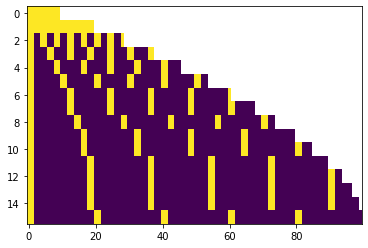

In [5]:
plt.imshow(color_matrix.T, aspect = 'auto', interpolation = 'nearest')

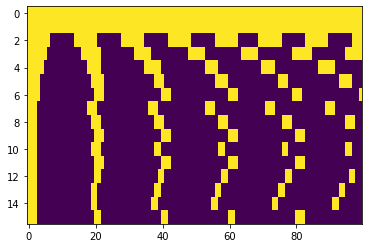

In [6]:
plt.imshow(color_theta_matrix.T, aspect = 'auto', interpolation = 'nearest')

# Generates mesh

In [7]:
# Init

previous_r = 0

rs.append(previous_r)
zs.append(0)

xs = 0
ys = 0

coords.append([[xs],[ys]])

meshs.append([
    [0]*nb_theta_mesh,
    [previous_r * np.sin(theta) for theta in (2*np.pi)*np.arange(nb_theta_mesh)/nb_theta_mesh], 
    [previous_r * np.cos(theta) for theta in (2*np.pi)*np.arange(nb_theta_mesh)/nb_theta_mesh]
])

In [8]:
for idx in range(len(sequence)):
    
    
    current_nb_stitches = sequence[idx]

    current_circle = dict()
    current_circle['perimeter'] = current_nb_stitches * dTheta
    current_circle['radius'] = current_circle['perimeter'] / (2*np.pi)
    current_circle['dz'] = np.sqrt((dr ** 2) - ((current_circle['radius'] - previous_r) ** 2))
    
    # print(f'idx: {idx}\nPerimeter: {current_circle["perimeter"]}\nRadius: {current_circle["radius"]}\ndz: {current_circle["dz"]}\n\n')

    previous_r = current_circle['radius']

    rs.append(current_circle['radius'])
    zs.append(zs[-1] - current_circle['dz'])

    current_circle['theta'] = 2*np.pi * np.arange(current_nb_stitches)/current_nb_stitches
    current_circle['xs'] = [current_circle['perimeter'] * np.sin(theta) for theta in current_circle['theta']]
    current_circle['xs'].append(current_circle['xs'][0])
    current_circle['ys'] = [current_circle['perimeter'] * np.cos(theta) for theta in current_circle['theta']]
    current_circle['ys'].append(current_circle['ys'][0])
    
    coords.append([current_circle['xs'], current_circle['ys']])
    meshs.append([
        [zs[-1]]*nb_theta_mesh,
        [previous_r * np.sin(theta) for theta in (2*np.pi)*np.arange(nb_theta_mesh)/nb_theta_mesh], 
        [previous_r * np.cos(theta) for theta in (2*np.pi)*np.arange(nb_theta_mesh)/nb_theta_mesh]
    ])

## Display shape

## 3D plot

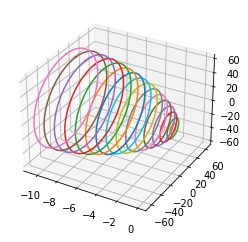

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for z, (xs, ys) in zip(zs, coords):
    
    local_zs = len(xs) * [z]
    ax.plot(local_zs, xs, ys)
    

(-69.11503837897544, 69.11503837897544, -69.11503837897544, 69.11503837897544)

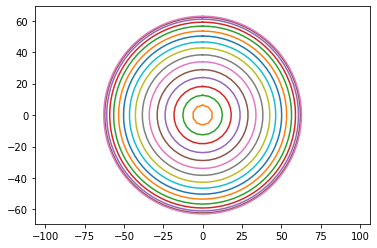

In [10]:
for xs,ys in coords:
    
    plt.plot(xs, ys)
    
plt.axis('equal')

## profile

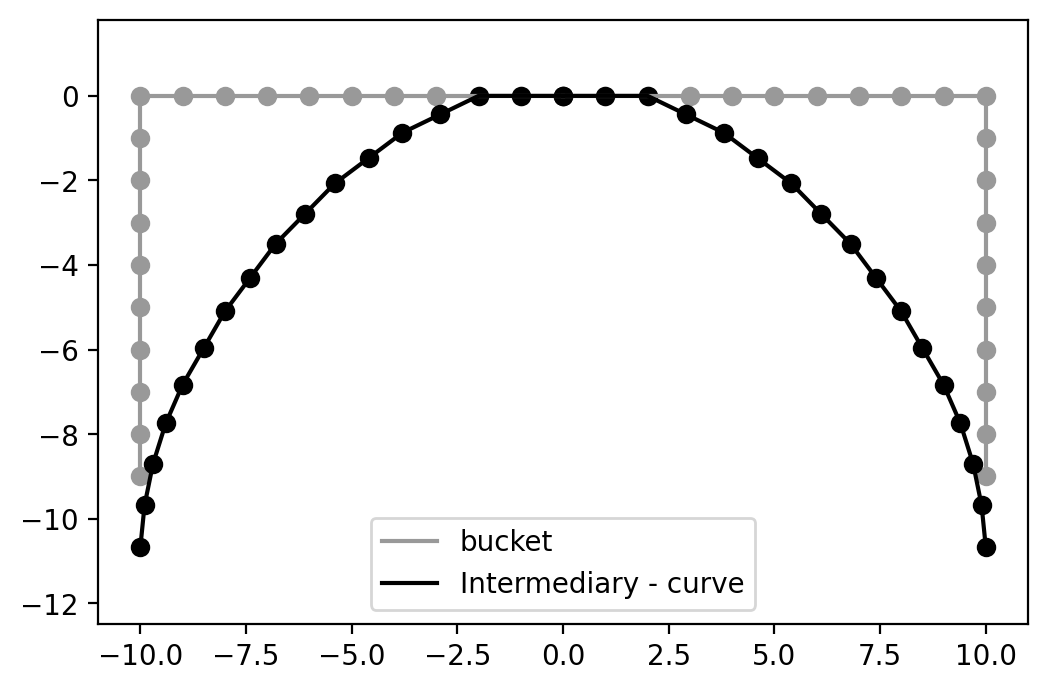

In [11]:
plt.figure(dpi = 200)

# Asymptotic bucket hat

nb_zs = 10

asympt_zs = 10*[0] + [-x for x in range(nb_zs)]
asympt_rs = [x for x in range(nb_zs+1)] + 9*[10]

plt.plot(asympt_rs, asympt_zs, color = [0.6, 0.6, 0.6, 1.], label = 'bucket')
plt.scatter(asympt_rs, asympt_zs, color = [0.6, 0.6, 0.6, 1.])

plt.plot(-np.array(asympt_rs), asympt_zs, color = [0.6, 0.6, 0.6, 1.])
plt.scatter(-np.array(asympt_rs), asympt_zs, color = [0.6, 0.6, 0.6, 1.])

# New design

plt.plot(rs, zs, color = 'k', label = 'Intermediary - curve')
plt.scatter(rs, zs, color = 'k')

plt.plot(-np.array(rs), zs, color = 'k')
plt.scatter(-np.array(rs), zs, color = 'k')

plt.axis('equal')
plt.legend(loc = 'lower center')

# Generate mesh

In [14]:
# version arbitrary color

meshs = np.array(meshs)

thetas_mesh = (2*np.pi)*np.arange(nb_theta_mesh)/nb_theta_mesh

color_palette = ['#f58d05', '#b445f5']

vertices = []
edges = []
colors = []
k = 0

for id_z in range(len(sequence)):
    for id_theta in range(nb_theta_mesh):
        vertices.append(
            [meshs[id_z,0, id_theta], meshs[id_z,1, id_theta], meshs[id_z, 2, id_theta]]
        )
        vertices.append(
            [meshs[id_z, 0, (id_theta+1)%nb_theta_mesh], meshs[id_z, 1, (id_theta+1)%nb_theta_mesh], meshs[id_z, 2, (id_theta+1)%nb_theta_mesh]]
        )
        vertices.append(
            [meshs[id_z+1, 0, (id_theta+1)%nb_theta_mesh], meshs[id_z+1, 1, (id_theta+1)%nb_theta_mesh], meshs[id_z+1, 2, (id_theta+1)%nb_theta_mesh]]
        )
        vertices.append(
            [meshs[id_z+1, 0, id_theta], meshs[id_z+1, 1, id_theta], meshs[id_z+1, 2, id_theta]]
        )
        
        edges.append([k,k+1,k+2])
        edges.append([k,k+2,k+3])
        
        if (id_theta % 10) in [0,1,2]:
        
            colors.append(color_palette[0])
            colors.append(color_palette[0])
        
        else:
            
            colors.append(color_palette[1])
            colors.append(color_palette[1])
        
        k = k+4
        
faces = [[vertices[k] for k in edge] for edge in edges]

## Display mesh

(-20.0, 0.0, -10.0, 10.0)

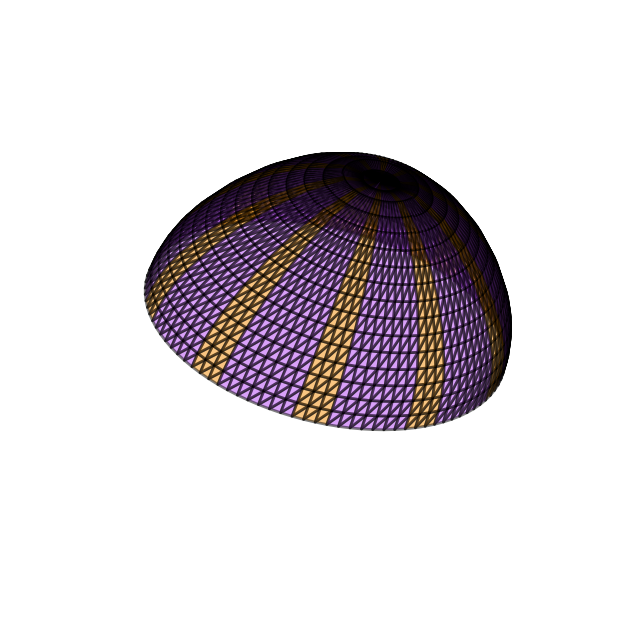

In [15]:
fig = plt.figure(dpi = 200)
ax = fig.add_subplot(111, projection='3d')

# Create 3D polygon collection
cube = Poly3DCollection(faces, alpha=0.5, facecolor=colors, edgecolor='black')
ax.add_collection3d(cube)

ax.set_xlim(-20, 0)
ax.set_ylim(-10, 10)
ax.set_zlim(-10, 10)

ax.view_init(elev=-45, azim=345)

plt.axis('off')